# Prototype Text vs NN Analysis

This notebook contains three cells:

1) **Summarize run4 outputs** — load `data/ground_truth_exp_all_data.pickle` and compare NN-projected prototype texts vs optimized textual prototypes (lengths and cosine-to-prototype).  
2) **Accuracy sanity check** — pick a dataset/model, load *(a)* the projection-based model weights and *(b)* the optimized-text model weights, then evaluate test accuracy/Macro-F1 for each.  
3) **LLM interpretability probe (100 trials)** — for random test instances, compare two random prototypes per model; ask an LLM (e.g., Qwen-7B) which prototype is closer, and record the LLM’s accuracy vs the model’s own latent choice.

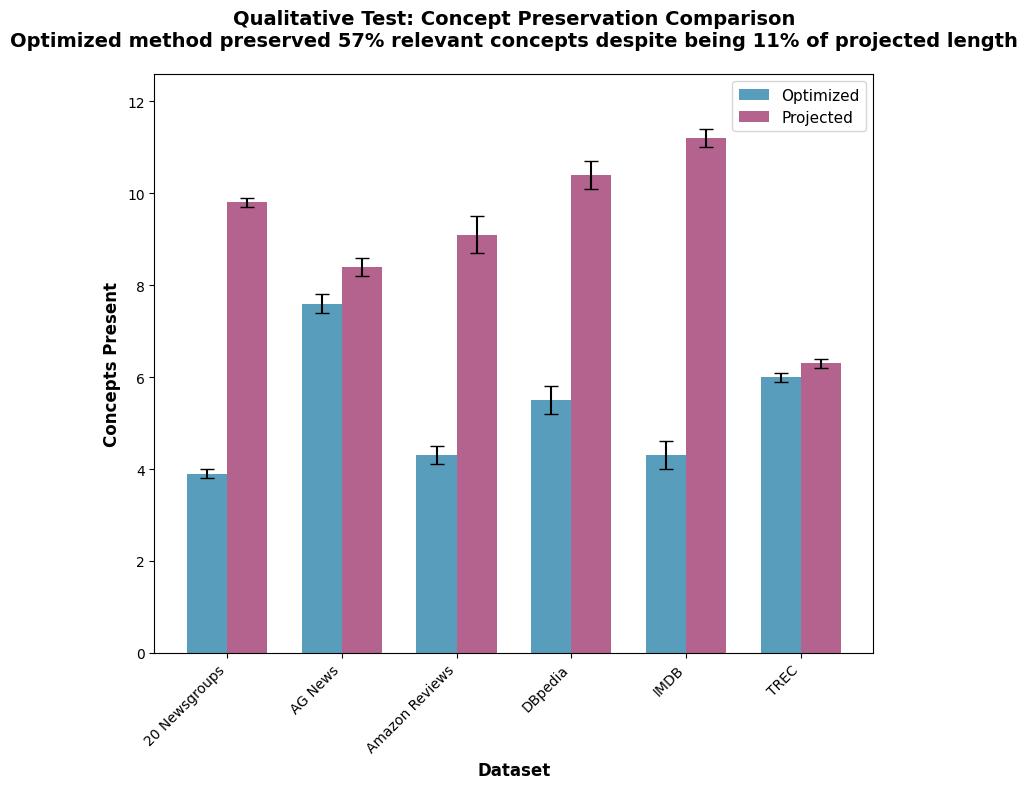

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table (6 datasets only, no Mean)
datasets = ['20 Newsgroups', 'AG News', 'Amazon Reviews', 'DBpedia', 'IMDB', 'TREC']
optimized_values = [3.9, 7.6, 4.3, 5.5, 4.3, 6.0]
optimized_errors = [0.1, 0.2, 0.2, 0.3, 0.3, 0.1]
projected_values = [9.8, 8.4, 9.1, 10.4, 11.2, 6.3]
projected_errors = [0.1, 0.2, 0.4, 0.3, 0.2, 0.1]

# Set up the plot (square format)
fig, ax = plt.subplots(figsize=(8, 8))

# Set the width of the bars and positions
bar_width = 0.35
x_pos = np.arange(len(datasets))

# Create the bars
bars1 = ax.bar(x_pos - bar_width/2, optimized_values, bar_width, 
               yerr=optimized_errors, capsize=5, label='Optimized', 
               color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x_pos + bar_width/2, projected_values, bar_width,
               yerr=projected_errors, capsize=5, label='Projected', 
               color='#A23B72', alpha=0.8)

# Customize the plot
ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('Concepts Present', fontsize=12, fontweight='bold')
ax.set_title('Qualitative Test: Concept Preservation Comparison\n' + 
             'Optimized method preserved 57% relevant concepts despite being 11% of projected length',
             fontsize=14, fontweight='bold', pad=20)

# Set x-axis labels
ax.set_xticks(x_pos)
ax.set_xticklabels(datasets, rotation=45, ha='right')

# Add legend
ax.legend(fontsize=11)

# Set y-axis to start from 0
ax.set_ylim(0, max(projected_values) + max(projected_errors) + 1)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

# Optional: Save the plot
# plt.savefig('qualitative_test_results.png', dpi=300, bbox_inches='tight')

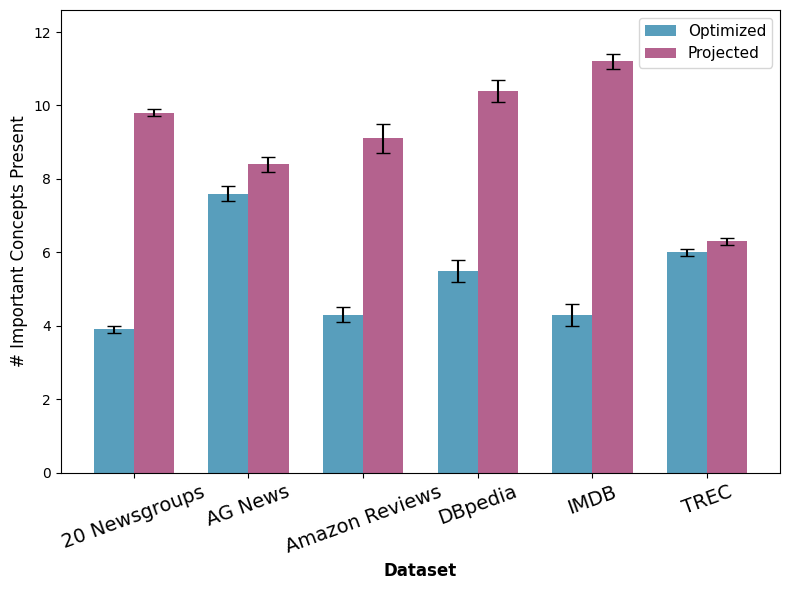

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table (Mean removed)
datasets = ['20 Newsgroups', 'AG News', 'Amazon Reviews', 'DBpedia', 'IMDB', 'TREC']
optimized_values = [3.9, 7.6, 4.3, 5.5, 4.3, 6.0]
optimized_errors = [0.1, 0.2, 0.2, 0.3, 0.3, 0.1]
projected_values = [9.8, 8.4, 9.1, 10.4, 11.2, 6.3]
projected_errors = [0.1, 0.2, 0.4, 0.3, 0.2, 0.1]

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Set the width of the bars and positions
bar_width = 0.35
x_pos = np.arange(len(datasets))

# Define colors - consistent colors for all bars
optimized_color = '#2E86AB'
projected_color = '#A23B72'

# Create the bars
bars1 = ax.bar(x_pos - bar_width/2, optimized_values, bar_width, 
               yerr=optimized_errors, capsize=5, label='Optimized', 
               color=optimized_color, alpha=0.8)
bars2 = ax.bar(x_pos + bar_width/2, projected_values, bar_width,
               yerr=projected_errors, capsize=5, label='Projected', 
               color=projected_color, alpha=0.8)

# Customize the plot
ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('# Important Concepts Present', fontsize=12)

# Set x-axis labels with modified rotation, size, and alignment
ax.set_xticks(x_pos)
ax.set_xticklabels(datasets, rotation=20, ha='center', fontsize=14)

# Add legend
ax.legend(fontsize=11)

# Set y-axis to start from 0
ax.set_ylim(0, max(projected_values) + max(projected_errors) + 1)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Optional: Save the plot
plt.savefig('qualitative_test_results.pdf', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [11]:
import os
import pickle
import pandas as pd
from pathlib import Path

def load_optimization_data(data_dir="data/len_run/"):
    """Load all available optimization data files"""
    data_files = []
    data_dir = Path(data_dir)
    
    for file_path in data_dir.glob("*.pickle"):
        try:
            with open(file_path, 'rb') as f:
                data = pickle.load(f)
            data_files.append((file_path.name, data))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    return data_files

def explore_available_data(data_files):
    """Show what datasets/models/configurations are available"""
    print("Available data configurations:")
    print("=" * 60)
    
    available_configs = set()
    
    for filename, data in data_files:
        print(f"\nFile: {filename}")
        for key in data.keys():
            if not key.endswith("_summary"):
                print(f"  Key: {key}")
                # Extract dataset/model info from key
                parts = key.split('_')
                if len(parts) >= 2:
                    available_configs.add((parts[0], parts[1]))  # dataset, model
                
                # Show prototype count for this configuration
                if isinstance(data[key], list) and len(data[key]) > 0:
                    num_prototypes = len(data[key])
                    print(f"    - {num_prototypes} prototypes")
                    
                    # Show iteration count for first prototype
                    if 'best_guess_history' in data[key][0]:
                        num_iters = len(data[key][0]['best_guess_history'])
                        print(f"    - {num_iters} iterations per prototype")
    
    print(f"\nUnique dataset/model combinations found: {sorted(available_configs)}")
    return available_configs

def visualize_prototype_trajectory(data_files, dataset, model, seed, prototype_idx, 
                                 llm_copies=3, max_text_length=100):
    """
    Visualize the textual prototype optimization trajectory
    
    Args:
        data_files: List of (filename, data) tuples
        dataset: Dataset name (e.g., 'imdb', 'amazon_reviews', 'agnews')
        model: Model name (e.g., 'bert', 'roberta', 'electra')
        seed: Seed number
        prototype_idx: Which prototype to visualize (0-indexed)
        llm_copies: Number of LLM copies used (default 3)
        max_text_length: Maximum characters to display per text (default 100)
    """
    
    # Look for the right file and key
    target_filename = f"optimization_exp_all_data_seed{seed}.pickle"
    target_key = f"{dataset}_{model}_latent_optim_{llm_copies}llms"
    
    found_data = None
    for filename, data in data_files:
        if filename == target_filename and target_key in data:
            found_data = data[target_key]
            break
    
    if found_data is None:
        print(f"Data not found for:")
        print(f"  Dataset: {dataset}")
        print(f"  Model: {model}")
        print(f"  Seed: {seed}")
        print(f"  LLM copies: {llm_copies}")
        print(f"  Expected file: {target_filename}")
        print(f"  Expected key: {target_key}")
        return
    
    if prototype_idx >= len(found_data):
        print(f"Prototype index {prototype_idx} not found. Available: 0-{len(found_data)-1}")
        return
    
    prototype_data = found_data[prototype_idx]
    
    if 'best_guess_history' not in prototype_data:
        print("No best_guess_history found in this data")
        return
    
    # Extract the trajectory
    best_guesses = prototype_data['best_guess_history']
    
    print(f"Textual Prototype Optimization Trajectory")
    print(f"Dataset: {dataset} | Model: {model} | Seed: {seed} | Prototype: {prototype_idx}")
    print("=" * 80)
    print(f"{'Iteration':<10} | {'Best Guess Text'}")
    print("-" * 80)
    
    for iteration, text in enumerate(best_guesses):
        # Truncate text if too long
        display_text = text if len(text) <= max_text_length else text[:max_text_length] + "..."
        # Replace newlines with spaces for cleaner display
        display_text = display_text.replace('\n', ' ').replace('\r', ' ')
        print(f"{iteration:<10} | {display_text}")
    
    # Show similarity scores if available
    if 'max_similarity' in prototype_data:
        similarities = prototype_data['max_similarity']
        print(f"\nSimilarity Scores:")
        print(f"{'Iteration':<10} | {'Max Similarity'}")
        print("-" * 25)
        for iteration, sim in enumerate(similarities):
            print(f"{iteration:<10} | {sim:.6f}")
    
    print(f"\nFinal Statistics:")
    print(f"Total iterations: {len(best_guesses)}")
    if 'max_similarity' in prototype_data:
        print(f"Initial similarity: {prototype_data['max_similarity'][0]:.6f}")
        print(f"Final similarity: {prototype_data['max_similarity'][-1]:.6f}")
        improvement = prototype_data['max_similarity'][-1] - prototype_data['max_similarity'][0]
        print(f"Improvement: {improvement:.6f}")

# Usage example:
if __name__ == "__main__":
    # Step 1: Load all data
    data_files = load_optimization_data("data/acc_run/")
    
    # # Step 2: Explore what's available
    # available_configs = explore_available_data(data_files)
    
    # Step 3: Choose specific configuration to visualize
    # Example usage (modify these parameters):
    visualize_prototype_trajectory(
        data_files=data_files,
        dataset="trec",        # Choose: imdb, amazon_reviews, agnews
        model="electra",          # Choose: bert, roberta, electra
        seed=0,               # Choose: 0, 1, 2, etc.
        prototype_idx=3,      # Choose: 0, 1, 2, etc.
        llm_copies=3,         # Usually 3
        max_text_length=100   # Adjust for display
    )

Textual Prototype Optimization Trajectory
Dataset: trec | Model: electra | Seed: 0 | Prototype: 3
Iteration  | Best Guess Text
--------------------------------------------------------------------------------
0          | What is the name for the day after the Nones in the Roman calendar?
1          | What is the name for the day after the Nones in the Roman calendar?
2          | What is the name for the day after the Nones in the Roman calendar?
3          | What are dinosaur droppings called?
4          | What are dinosaur droppings called?
5          | What is the name of the Jewish calendar?
6          | What is the name of the Jewish calendar?
7          | What is the name of the Jewish calendar?
8          | What is the name of the Jewish calendar?
9          | What is the name of the Jewish calendar?
10         | What is the name of the Jewish calendar?
11         | What is the name of the Jewish calendar?
12         | What is the name of the Jewish calendar?
13         | What i

In [20]:
import os
import pickle
import pandas as pd
import numpy as np
from pathlib import Path

def load_optimization_data(data_dir="data/len_run/"):
    """Load all available optimization data files"""
    data_files = []
    data_dir = Path(data_dir)
    
    for file_path in data_dir.glob("*.pickle"):
        try:
            with open(file_path, 'rb') as f:
                data = pickle.load(f)
            data_files.append((file_path.name, data))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    return data_files

def get_available_datasets_and_seeds(data_files):
    """Extract available datasets and seeds from the data keys"""
    datasets = set()
    seeds = set()
    
    for filename, data in data_files:
        # Extract seed from filename
        if "seed" in filename:
            try:
                seed_part = filename.split("seed")[1].replace(".pickle", "")
                seed = int(seed_part)
                seeds.add(seed)
            except:
                pass
        
        # Extract datasets from keys
        for key in data.keys():
            if key.endswith("_latent_optim_3llms") and not key.endswith("_summary"):
                dataset_model_part = key.replace("_latent_optim_3llms", "")
                dataset_parts = dataset_model_part.split("_")[:-1]
                dataset = "_".join(dataset_parts)
                if dataset:
                    datasets.add(dataset)
    
    return sorted(datasets), sorted(seeds)

def analyze_prototype_lengths(data_files, model, seed, llm_copies=3):
    """
    Analyze character lengths of Stage A (optimized) and Stage B (nearest neighbor) prototypes
    """
    
    available_datasets, available_seeds = get_available_datasets_and_seeds(data_files)
    
    if seed not in available_seeds:
        print(f"Seed {seed} not found. Available seeds: {available_seeds}")
        return None
    
    # Find the file with the target seed
    target_file_data = None
    target_filename = None
    for filename, data in data_files:
        if f"seed{seed}" in filename:
            target_file_data = data
            target_filename = filename
            break
    
    if target_file_data is None:
        print(f"No file found for seed {seed}")
        return None
    
    print(f"Analyzing prototype lengths for model={model}, seed={seed}")
    print(f"Using file: {target_filename}")
    print("=" * 70)
    
    results_by_dataset = {}
    all_stage_a_lengths = []
    all_stage_b_lengths = []
    
    for dataset in available_datasets:
        target_key = f"{dataset}_{model}_latent_optim_{llm_copies}llms"
        
        if target_key not in target_file_data:
            print(f"Key not found for {dataset}: {target_key}")
            continue
        
        found_data = target_file_data[target_key]
        
        stage_a_lengths = []  # Final optimized texts
        stage_b_lengths = []  # Early nearest neighbor examples
        
        print(f"\nDataset: {dataset.upper()}")
        print("-" * 40)
        
        for prototype_idx, prototype_data in enumerate(found_data):
            # Stage A: Final optimized text
            final_guess = prototype_data.get('final_guess', '')
            stage_a_len = len(final_guess)
            stage_a_lengths.append(stage_a_len)
            all_stage_a_lengths.append(stage_a_len)
            
            # Stage B approximation: Early nearest neighbor
            early_example = prototype_data.get('early_example', '')
            stage_b_len = len(early_example)
            stage_b_lengths.append(stage_b_len)
            all_stage_b_lengths.append(stage_b_len)
            
            print(f"  Prototype {prototype_idx}:")
            print(f"    Stage A (optimized): {stage_a_len:4d} chars")
            print(f"    Stage B (nearest):   {stage_b_len:4d} chars")
            
            # Show text previews
            stage_a_preview = (final_guess[:60] + "...") if len(final_guess) > 60 else final_guess
            stage_b_preview = (early_example[:60] + "...") if len(early_example) > 60 else early_example
            print(f"    Stage A text: {stage_a_preview}")
            print(f"    Stage B text: {stage_b_preview}")
            print()
        
        # Dataset statistics
        dataset_stats = {
            'dataset': dataset,
            'num_prototypes': len(stage_a_lengths),
            'stage_a_mean': np.mean(stage_a_lengths),
            'stage_a_std': np.std(stage_a_lengths),
            'stage_a_min': np.min(stage_a_lengths),
            'stage_a_max': np.max(stage_a_lengths),
            'stage_b_mean': np.mean(stage_b_lengths),
            'stage_b_std': np.std(stage_b_lengths),
            'stage_b_min': np.min(stage_b_lengths),
            'stage_b_max': np.max(stage_b_lengths),
            'length_difference_mean': np.mean(np.array(stage_a_lengths) - np.array(stage_b_lengths))
        }
        
        results_by_dataset[dataset] = dataset_stats
        
        print(f"Dataset {dataset} Summary:")
        print(f"  Stage A (Optimized):     μ={dataset_stats['stage_a_mean']:.1f}, σ={dataset_stats['stage_a_std']:.1f}, range=[{dataset_stats['stage_a_min']}-{dataset_stats['stage_a_max']}]")
        print(f"  Stage B (Nearest Neighbor): μ={dataset_stats['stage_b_mean']:.1f}, σ={dataset_stats['stage_b_std']:.1f}, range=[{dataset_stats['stage_b_min']}-{dataset_stats['stage_b_max']}]")
        print(f"  Difference (A-B):        μ={dataset_stats['length_difference_mean']:.1f}")
    
    # Overall statistics
    print("\n" + "=" * 70)
    print("OVERALL STATISTICS")
    print("=" * 70)
    
    if all_stage_a_lengths and all_stage_b_lengths:
        overall_stats = {
            'total_prototypes': len(all_stage_a_lengths),
            'stage_a_overall_mean': np.mean(all_stage_a_lengths),
            'stage_a_overall_std': np.std(all_stage_a_lengths),
            'stage_a_overall_min': np.min(all_stage_a_lengths),
            'stage_a_overall_max': np.max(all_stage_a_lengths),
            'stage_b_overall_mean': np.mean(all_stage_b_lengths),
            'stage_b_overall_std': np.std(all_stage_b_lengths),
            'stage_b_overall_min': np.min(all_stage_b_lengths),
            'stage_b_overall_max': np.max(all_stage_b_lengths),
            'overall_difference_mean': np.mean(np.array(all_stage_a_lengths) - np.array(all_stage_b_lengths))
        }
        
        print(f"Total Prototypes Analyzed: {overall_stats['total_prototypes']}")
        print(f"Datasets: {list(results_by_dataset.keys())}")
        print()
        print(f"Stage A (Optimized Text) Overall:")
        print(f"  Mean: {overall_stats['stage_a_overall_mean']:.1f} characters")
        print(f"  Std:  {overall_stats['stage_a_overall_std']:.1f} characters")
        print(f"  Range: [{overall_stats['stage_a_overall_min']}-{overall_stats['stage_a_overall_max']}] characters")
        print()
        print(f"Stage B (Nearest Neighbor) Overall:")
        print(f"  Mean: {overall_stats['stage_b_overall_mean']:.1f} characters")
        print(f"  Std:  {overall_stats['stage_b_overall_std']:.1f} characters")  
        print(f"  Range: [{overall_stats['stage_b_overall_min']}-{overall_stats['stage_b_overall_max']}] characters")
        print()
        print(f"Length Difference (Stage A - Stage B):")
        print(f"  Mean Difference: {overall_stats['overall_difference_mean']:.1f} characters")
        
        # Create summary DataFrame
        summary_df = pd.DataFrame(list(results_by_dataset.values()))
        summary_df = summary_df.round(1)
        
        print("\nSummary Table:")
        print("-" * 70)
        print(f"{'Dataset':<15} {'#Protos':<8} {'Stage A μ':<10} {'Stage B μ':<10} {'Diff μ':<8}")
        print("-" * 70)
        for _, row in summary_df.iterrows():
            print(f"{row['dataset']:<15} {row['num_prototypes']:<8} {row['stage_a_mean']:<10.1f} {row['stage_b_mean']:<10.1f} {row['length_difference_mean']:<8.1f}")
        
        return {
            'by_dataset': results_by_dataset,
            'overall': overall_stats,
            'summary_df': summary_df
        }
    else:
        print("No data found to analyze!")
        return None

# Usage:
if __name__ == "__main__":
    # Load all data
    data_files = load_optimization_data("data/len_run/")
    
    if not data_files:
        print("No data files found!")
    else:
        # Analyze prototype lengths
        results = analyze_prototype_lengths(
            data_files=data_files,
            model="bert",  # Change to 'roberta' or 'electra'
            seed=0         # Change seed as needed
        )
        
        if results:
            print("\nAnalysis complete!")
            # Access results like: results['overall']['stage_a_overall_mean']
        else:
            print("Analysis failed - no data found")

Analyzing prototype lengths for model=bert, seed=0
Using file: optimization_exp_all_data_seed0.pickle

Dataset: 20NEWSGROUPS
----------------------------------------
  Prototype 0:
    Stage A (optimized):   67 chars
    Stage B (nearest):    159 chars
    Stage A text: A call for greater awareness and action on a pressing social...
    Stage B text: Organization: Arizona State University
From: <CXNBK@ASUACAD....

  Prototype 1:
    Stage A (optimized):   42 chars
    Stage B (nearest):    254 chars
    Stage A text: The big win was a highlight of the season.
    Stage B text: From: boell@hpcc01.corp.hp.com (Donald P Boell)
Subject: Re:...

  Prototype 2:
    Stage A (optimized):   83 chars
    Stage B (nearest):    463 chars
    Stage A text: Canada and Sweden face off in a highly anticipated match in ...
    Stage B text: From: joe13+@pitt.edu (Joseph B Stiehm)
Subject: Re: How to ...

  Prototype 3:
    Stage A (optimized):   92 chars
    Stage B (nearest):   2257 chars
    Stage A 

In [22]:
# Load and analyze
data_files = load_optimization_data("data/acc_run/")

# Analyze BERT model with seed 0
results = analyze_prototype_lengths(data_files, model="bert", seed=0)

# Or analyze different model/seed combinations
for model in ["bert", "roberta", "electra"]:
    print(f"\n{'='*80}")
    print(f"ANALYZING {model.upper()}")
    print(f"{'='*80}")
    results = analyze_prototype_lengths(data_files, model=model, seed=0)

Analyzing prototype lengths for model=bert, seed=0
Using file: optimization_exp_all_data_seed0.pickle

Dataset: 20NEWSGROUPS
----------------------------------------
  Prototype 0:
    Stage A (optimized):   90 chars
    Stage B (nearest):    471 chars
    Stage A text: Advancing the cause of human dignity and well-being through ...
    Stage B text: From: pgf5@cunixb.cc.columbia.edu (Peter Garfiel Freeman)
Su...

  Prototype 1:
    Stage A (optimized):  114 chars
    Stage B (nearest):    254 chars
    Stage A text: Boston will host a state-of-the-art baseball stadium, a faci...
    Stage B text: From: boell@hpcc01.corp.hp.com (Donald P Boell)
Subject: Re:...

  Prototype 2:
    Stage A (optimized):   42 chars
    Stage B (nearest):    700 chars
    Stage A text: Canada wins big at the World Championships
    Stage B text: From: r_turgeo@oz.plymouth.edu (Randy S. Turgeon)
Subject: R...

  Prototype 3:
    Stage A (optimized):   72 chars
    Stage B (nearest):    768 chars
    Stage A 

In [29]:
(58.6 + 138.6 + 47 + 160 + 61.2 + 127) / 6

98.73333333333333

In [30]:
(1014 + 300.3 + 2767.0 + 190 + 869.9 + 48.0)/6

864.8666666666667

In [31]:
98.73333333333333/864.8666666666667

0.11416017883296077

In [28]:
# Analyze just BERT for agnews
result = analyze_agnews_prototype_lengths(
    file_path="data/optimization_exp_all_data_seed0_agnews.pickle", 
    model="bert"
)

# Or analyze all models at once
all_results = analyze_all_agnews_models("data/optimization_exp_all_data_seed0_agnews.pickle")

Loaded: data/optimization_exp_all_data_seed0_agnews.pickle
Available keys: ['agnews_bert_latent_optim_3llms', 'agnews_bert_latent_optim_3llms_summary', 'agnews_roberta_latent_optim_3llms', 'agnews_roberta_latent_optim_3llms_summary', 'agnews_electra_latent_optim_3llms', 'agnews_electra_latent_optim_3llms_summary']
Analyzing AGNews prototype lengths for model=bert

Dataset: AGNEWS
----------------------------------------
  Prototype 0:
    Stage A (optimized):  249 chars
    Stage B (nearest):    249 chars
    Stage A text: ARSENAL eased into the knock-out stages of the Champions League after beating Ro...
    Stage B text: Arsenal eased into the knock-out stages of the Champions League after beating Ro...

  Prototype 1:
    Stage A (optimized):   96 chars
    Stage B (nearest):    165 chars
    Stage A text: Manchester United's Glazer family announces significant investment in Manchester...
    Stage B text: Manchester United fans have promised Malcolm Glazer a continued campaign of h

In [27]:
import os
import pickle
import pandas as pd
import numpy as np
from pathlib import Path

def analyze_agnews_prototype_lengths(file_path="data/optimization_exp_all_data_seed0_agnews.pickle", 
                                   model="bert", llm_copies=3):
    """
    Analyze character lengths for agnews dataset specifically
    """
    
    # Load the specific file
    try:
        with open(file_path, 'rb') as f:
            data = pickle.load(f)
        print(f"Loaded: {file_path}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None
    
    # Look for the target key
    target_key = f"agnews_{model}_latent_optim_{llm_copies}llms"
    
    print(f"Available keys: {list(data.keys())}")
    
    if target_key not in data:
        print(f"Target key not found: {target_key}")
        return None
    
    found_data = data[target_key]
    
    print(f"Analyzing AGNews prototype lengths for model={model}")
    print("=" * 70)
    
    stage_a_lengths = []  # Final optimized texts
    stage_b_lengths = []  # Early nearest neighbor examples
    
    print(f"\nDataset: AGNEWS")
    print("-" * 40)
    
    for prototype_idx, prototype_data in enumerate(found_data):
        # Stage A: Final optimized text
        final_guess = prototype_data.get('final_guess', '')
        stage_a_len = len(final_guess)
        stage_a_lengths.append(stage_a_len)
        
        # Stage B approximation: Early nearest neighbor
        early_example = prototype_data.get('early_example', '')
        stage_b_len = len(early_example)
        stage_b_lengths.append(stage_b_len)
        
        print(f"  Prototype {prototype_idx}:")
        print(f"    Stage A (optimized): {stage_a_len:4d} chars")
        print(f"    Stage B (nearest):   {stage_b_len:4d} chars")
        
        # Show text previews
        stage_a_preview = (final_guess[:80] + "...") if len(final_guess) > 80 else final_guess
        stage_b_preview = (early_example[:80] + "...") if len(early_example) > 80 else early_example
        print(f"    Stage A text: {stage_a_preview}")
        print(f"    Stage B text: {stage_b_preview}")
        print()
    
    # Dataset statistics
    dataset_stats = {
        'dataset': 'agnews',
        'num_prototypes': len(stage_a_lengths),
        'stage_a_mean': np.mean(stage_a_lengths),
        'stage_a_std': np.std(stage_a_lengths),
        'stage_a_min': np.min(stage_a_lengths),
        'stage_a_max': np.max(stage_a_lengths),
        'stage_b_mean': np.mean(stage_b_lengths),
        'stage_b_std': np.std(stage_b_lengths),
        'stage_b_min': np.min(stage_b_lengths),
        'stage_b_max': np.max(stage_b_lengths),
        'length_difference_mean': np.mean(np.array(stage_a_lengths) - np.array(stage_b_lengths))
    }
    
    print(f"AGNews Summary:")
    print(f"  Number of prototypes: {dataset_stats['num_prototypes']}")
    print(f"  Stage A (Optimized):     μ={dataset_stats['stage_a_mean']:.1f}, σ={dataset_stats['stage_a_std']:.1f}, range=[{dataset_stats['stage_a_min']}-{dataset_stats['stage_a_max']}]")
    print(f"  Stage B (Nearest Neighbor): μ={dataset_stats['stage_b_mean']:.1f}, σ={dataset_stats['stage_b_std']:.1f}, range=[{dataset_stats['stage_b_min']}-{dataset_stats['stage_b_max']}]")
    print(f"  Difference (A-B):        μ={dataset_stats['length_difference_mean']:.1f}")
    
    print("\n" + "=" * 70)
    print("DETAILED BREAKDOWN")
    print("=" * 70)
    
    print(f"{'Prototype':<12} {'Stage A':<10} {'Stage B':<10} {'Difference':<10}")
    print("-" * 50)
    for i, (a_len, b_len) in enumerate(zip(stage_a_lengths, stage_b_lengths)):
        diff = a_len - b_len
        print(f"Prototype {i:<4} {a_len:<10} {b_len:<10} {diff:<10}")
    
    return dataset_stats

# Quick usage for all available models
def analyze_all_agnews_models(file_path="data/optimization_exp_all_data_seed0_agnews.pickle"):
    """Analyze all available models for agnews"""
    
    models_to_try = ["bert", "roberta", "electra"]
    results = {}
    
    for model in models_to_try:
        print(f"\n{'='*80}")
        print(f"ANALYZING AGNEWS - {model.upper()}")
        print(f"{'='*80}")
        
        result = analyze_agnews_prototype_lengths(file_path, model=model)
        if result:
            results[model] = result
        else:
            print(f"No data found for {model}")
    
    # Summary comparison
    if results:
        print(f"\n{'='*80}")
        print(f"CROSS-MODEL COMPARISON - AGNEWS")
        print(f"{'='*80}")
        
        print(f"{'Model':<10} {'#Protos':<8} {'Stage A μ':<10} {'Stage B μ':<10} {'Diff μ':<8}")
        print("-" * 50)
        for model, stats in results.items():
            print(f"{model:<10} {stats['num_prototypes']:<8} {stats['stage_a_mean']:<10.1f} {stats['stage_b_mean']:<10.1f} {stats['length_difference_mean']:<8.1f}")
    
    return results

# Usage:
if __name__ == "__main__":
    # Analyze specific model
    result = analyze_agnews_prototype_lengths(
        file_path="data/optimization_exp_all_data_seed0_agnews.pickle", 
        model="bert"
    )
    
    # Or analyze all available models
    # all_results = analyze_all_agnews_models("data/optimization_exp_all_data_seed0_agnews.pickle")

Loaded: data/optimization_exp_all_data_seed0_agnews.pickle
Available keys: ['agnews_bert_latent_optim_3llms', 'agnews_bert_latent_optim_3llms_summary', 'agnews_roberta_latent_optim_3llms', 'agnews_roberta_latent_optim_3llms_summary', 'agnews_electra_latent_optim_3llms', 'agnews_electra_latent_optim_3llms_summary']
Analyzing AGNews prototype lengths for model=bert

Dataset: AGNEWS
----------------------------------------
  Prototype 0:
    Stage A (optimized):  249 chars
    Stage B (nearest):    249 chars
    Stage A text: ARSENAL eased into the knock-out stages of the Champions League after beating Ro...
    Stage B text: Arsenal eased into the knock-out stages of the Champions League after beating Ro...

  Prototype 1:
    Stage A (optimized):   96 chars
    Stage B (nearest):    165 chars
    Stage A text: Manchester United's Glazer family announces significant investment in Manchester...
    Stage B text: Manchester United fans have promised Malcolm Glazer a continued campaign of h

In [18]:
import os
import pickle
import pandas as pd
from pathlib import Path

def load_optimization_data(data_dir="data/len_run/"):
    """Load all available optimization data files"""
    data_files = []
    data_dir = Path(data_dir)
    
    print(f"Looking for files in: {data_dir}")
    
    for file_path in data_dir.glob("*.pickle"):
        try:
            with open(file_path, 'rb') as f:
                data = pickle.load(f)
            data_files.append((file_path.name, data))
            print(f"Loaded: {file_path.name}")
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    print(f"Total files loaded: {len(data_files)}")
    return data_files

def get_available_datasets_and_seeds(data_files):
    """Extract available datasets and seeds from the data keys"""
    datasets = set()
    seeds = set()
    
    print("\nAnalyzing available datasets from data keys:")
    for filename, data in data_files:
        print(f"  File: {filename}")
        
        # Extract seed from filename
        if "seed" in filename:
            try:
                seed_part = filename.split("seed")[1].replace(".pickle", "")
                seed = int(seed_part)
                seeds.add(seed)
            except:
                pass
        
        # Extract datasets from keys
        for key in data.keys():
            if key.endswith("_latent_optim_3llms") and not key.endswith("_summary"):
                # Key format: "imdb_bert_latent_optim_3llms"
                parts = key.split("_")
                if len(parts) >= 2:
                    # Find where "_latent_optim_3llms" starts
                    if "_latent_optim_3llms" in key:
                        dataset_model_part = key.replace("_latent_optim_3llms", "")
                        # Split and take all but the last part (which should be the model)
                        dataset_parts = dataset_model_part.split("_")[:-1]
                        dataset = "_".join(dataset_parts)
                        if dataset:  # Make sure it's not empty
                            datasets.add(dataset)
        
        print(f"    Found keys: {[k for k in data.keys() if '_latent_optim_3llms' in k and not k.endswith('_summary')][:3]}...")
    
    print(f"Unique datasets found: {sorted(datasets)}")
    print(f"Seeds found: {sorted(seeds)}")
    return sorted(datasets), sorted(seeds)

def save_all_datasets_trajectories(data_files, model, seed, llm_copies=3, 
                                 output_dir="prototype_trajectories/"):
    """
    Save trajectory data for all available datasets with the specified model/seed
    """
    
    # Get available datasets and seeds
    available_datasets, available_seeds = get_available_datasets_and_seeds(data_files)
    print(f"\nTarget model: {model}, seed: {seed}")
    print(f"Available datasets: {available_datasets}")
    print(f"Available seeds: {available_seeds}")
    
    if not available_datasets:
        print("No datasets found in the data files!")
        return None, None
    
    if seed not in available_seeds:
        print(f"Seed {seed} not found. Available seeds: {available_seeds}")
        return None, None
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    all_rows = []
    processed_datasets = []
    
    # Find the file with the target seed
    target_file_data = None
    target_filename = None
    for filename, data in data_files:
        if f"seed{seed}" in filename:
            target_file_data = data
            target_filename = filename
            break
    
    if target_file_data is None:
        print(f"No file found for seed {seed}")
        return None, None
    
    print(f"Using file: {target_filename}")
    
    for dataset in available_datasets:
        print(f"\n--- Processing dataset: {dataset} ---")
        
        # Look for the right key
        target_key = f"{dataset}_{model}_latent_optim_{llm_copies}llms"
        
        print(f"Looking for key: {target_key}")
        
        if target_key not in target_file_data:
            print(f"  Key not found: {target_key}")
            print(f"  Available keys: {[k for k in target_file_data.keys() if dataset in k]}")
            continue
        
        found_data = target_file_data[target_key]
        print(f"  Found target key!")
        
        # Process this dataset's prototypes
        dataset_rows = []
        print(f"  Processing {len(found_data)} prototypes...")
        
        for prototype_idx, prototype_data in enumerate(found_data):
            if 'best_guess_history' not in prototype_data:
                print(f"    Warning: No best_guess_history for prototype {prototype_idx}")
                continue
            
            best_guesses = prototype_data['best_guess_history']
            similarities = prototype_data.get('max_similarity', [None] * len(best_guesses))
            
            print(f"    Prototype {prototype_idx}: {len(best_guesses)} iterations")
            
            for iteration, text in enumerate(best_guesses):
                row = {
                    'prototype_index': prototype_idx,
                    'iteration': iteration,
                    'best_guess_text': text,
                    'max_similarity': similarities[iteration] if iteration < len(similarities) else None,
                    'dataset': dataset,
                    'model': model,
                    'seed': seed
                }
                dataset_rows.append(row)
                all_rows.append(row)
        
        if dataset_rows:
            print(f"  Added {len(dataset_rows)} rows from {len(found_data)} prototypes")
            processed_datasets.append(dataset)
        else:
            print(f"  No valid data found for {dataset}")
    
    if not all_rows:
        print("\nNo data found to save across all datasets!")
        return None, None
    
    # Create DataFrame with only the required columns
    df = pd.DataFrame(all_rows)
    
    # Save to CSV
    output_filename = f"all_datasets_{model}_seed{seed}_trajectories.csv"
    output_path = os.path.join(output_dir, output_filename)
    df.to_csv(output_path, index=False)
    
    print(f"\n{'='*60}")
    print(f"SAVED: {output_path}")
    print(f"Shape: {df.shape}")
    print(f"Datasets included: {processed_datasets}")
    print(f"Total prototypes: {df['prototype_index'].nunique()}")
    print(f"Max iterations: {df['iteration'].max() + 1}")
    
    # Show breakdown by dataset
    print(f"\nBreakdown by dataset:")
    print("-" * 40)
    dataset_summary = df.groupby('dataset').agg({
        'prototype_index': 'nunique',
        'iteration': 'max',
        'max_similarity': ['min', 'max']
    }).round(4)
    dataset_summary.columns = ['num_prototypes', 'max_iterations', 'min_similarity', 'max_similarity']
    dataset_summary['max_iterations'] = dataset_summary['max_iterations'] + 1  # Convert to count
    print(dataset_summary)
    
    return output_path, df

# Usage with error handling:
if __name__ == "__main__":
    # Load all data
    data_files = load_optimization_data("data/len_run/")
    
    if not data_files:
        print("No data files found!")
    else:
        # Save all datasets for BERT model with seed 0
        result = save_all_datasets_trajectories(
            data_files=data_files,
            model="bert",  # Change this to 'roberta' or 'electra' as needed
            seed=0        # Change this to different seed as needed
        )
        
        if result[0] is not None:
            output_path, df = result
            print(f"Success! Saved to {output_path}")
        else:
            print("No data was found to process.")

Looking for files in: data/len_run
Loaded: optimization_exp_all_data_seed3.pickle
Loaded: optimization_exp_all_data_seed2.pickle
Loaded: optimization_exp_all_data_seed5.pickle
Loaded: optimization_exp_all_data_seed0.pickle
Loaded: optimization_exp_all_data_seed1.pickle
Loaded: optimization_exp_all_data_seed4.pickle
Total files loaded: 6

Analyzing available datasets from data keys:
  File: optimization_exp_all_data_seed3.pickle
    Found keys: ['20newsgroups_roberta_latent_optim_3llms', '20newsgroups_electra_latent_optim_3llms']...
  File: optimization_exp_all_data_seed2.pickle
    Found keys: ['imdb_bert_latent_optim_3llms', 'imdb_roberta_latent_optim_3llms', 'imdb_electra_latent_optim_3llms']...
  File: optimization_exp_all_data_seed5.pickle
    Found keys: ['20newsgroups_bert_latent_optim_3llms']...
  File: optimization_exp_all_data_seed0.pickle
    Found keys: ['imdb_bert_latent_optim_3llms', 'imdb_roberta_latent_optim_3llms', 'imdb_electra_latent_optim_3llms']...
  File: optimizat

In [19]:
# Load the data
data_files = load_optimization_data("data/acc_run/")

# Try to save with error handling
result = save_all_datasets_trajectories(
    data_files=data_files,
    model="bert",
    seed=0
)

if result[0] is not None:
    output_path, df = result
    print(f"Successfully saved to: {output_path}")
    print(f"DataFrame shape: {df.shape}")
    print(f"First few rows:")
    print(df.head())
else:
    print("No data found - check the debug output above")

Looking for files in: data/acc_run
Loaded: optimization_exp_all_data_seed3.pickle
Loaded: optimization_exp_all_data_seed2.pickle
Loaded: optimization_exp_all_data_seed0.pickle
Loaded: optimization_exp_all_data_seed1.pickle
Loaded: optimization_exp_all_data_seed4.pickle
Total files loaded: 5

Analyzing available datasets from data keys:
  File: optimization_exp_all_data_seed3.pickle
    Found keys: ['20newsgroups_roberta_latent_optim_3llms', '20newsgroups_electra_latent_optim_3llms', 'dbpedia_bert_latent_optim_3llms']...
  File: optimization_exp_all_data_seed2.pickle
    Found keys: ['20newsgroups_bert_latent_optim_3llms', '20newsgroups_roberta_latent_optim_3llms', 'dbpedia_bert_latent_optim_3llms']...
  File: optimization_exp_all_data_seed0.pickle
    Found keys: ['20newsgroups_bert_latent_optim_3llms', '20newsgroups_roberta_latent_optim_3llms', '20newsgroups_electra_latent_optim_3llms']...
  File: optimization_exp_all_data_seed1.pickle
    Found keys: ['20newsgroups_bert_latent_optim_

/tmp/ipykernel_311783/1937897131.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98))


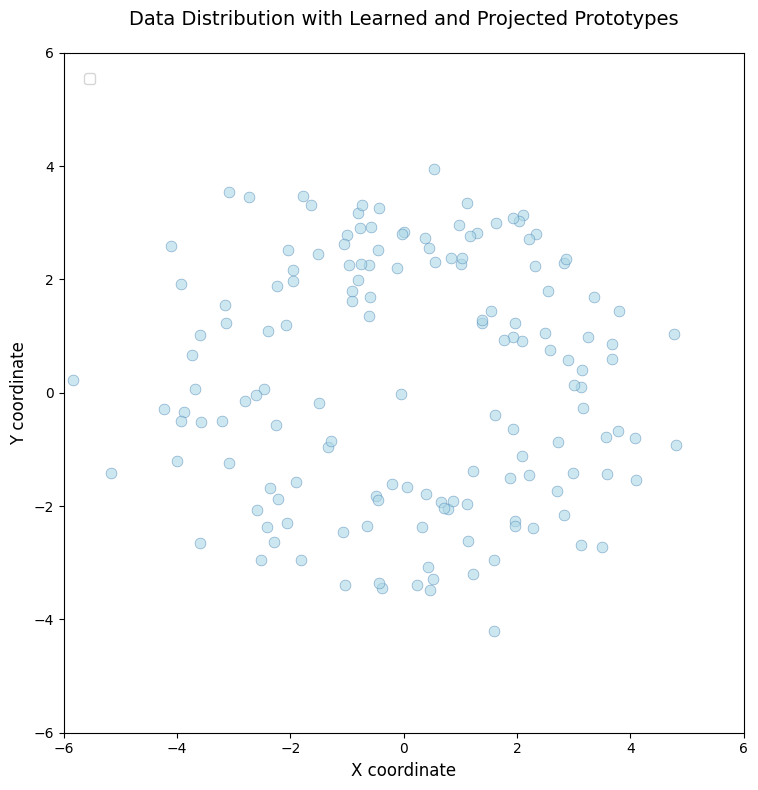

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate messy, scattered data distribution
n_points = 150
# Base circular distribution with noise
angles = np.random.uniform(0, 2*np.pi, n_points)
# Varying radii to make it messy (not perfect circle)
base_radii = np.random.normal(3, 0.8, n_points)  # Mean radius 3, std 0.8
# Add some random perturbation to make it more scattered
radii = np.abs(base_radii) + np.random.normal(0, 0.3, n_points)

# Convert to Cartesian coordinates
data_x = radii * np.cos(angles)
data_y = radii * np.sin(angles)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot data distribution as circles
ax.scatter(data_x, data_y, c='lightblue', s=60, alpha=0.6, 
           edgecolors='steelblue', linewidth=0.5)

# Customize the plot
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_xlabel('X coordinate', fontsize=12)
ax.set_ylabel('Y coordinate', fontsize=12)
ax.set_title('Data Distribution with Learned and Projected Prototypes', fontsize=14, pad=20)
# ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Add legend
ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98))

# # Add text annotations for the prototypes
# ax.text(learned_prototype[0] + 0.3, learned_prototype[1] + 0.3, 
#         'Learned\nPrototype', fontsize=10, ha='left', va='bottom',
#         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ax.text(projected_prototype[0] + 0.3, projected_prototype[1] - 0.5, 
#         'Projected\nPrototype', fontsize=10, ha='left', va='top',
#         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
# plt.show()

# Optional: Save the plot
plt.savefig('prototype_plot.pdf', dpi=300, bbox_inches='tight')

In [1]:

# --- Cell 1: Summarize NN vs Optimized Text Prototypes from run4 ---
import os, json, pickle
import pandas as pd

PICKLE_PATH = "data/ground_truth_exp_all_data.pickle"

def load_all_exp_data(path=PICKLE_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Couldn't find '{path}'. Please run your run4 script first.")
    with open(path, "rb") as f:
        data = pickle.load(f)
    if not isinstance(data, dict):
        raise ValueError("Loaded pickle does not contain a dict.")
    return data

def build_summary_df(all_exp_data):
    rows = []
    for key, exp_list in all_exp_data.items():
        if not key.endswith("_latent_optim"):
            continue
        # Companion summary (may include averages and weight paths)
        run_key = key
        summary_key = key + "_summary"
        run_summary = all_exp_data.get(summary_key, {})

        # Try to parse dataset+model from key pattern "<dataset>_<model>_latent_optim"
        parts = run_key.replace("_latent_optim", "").split("_")
        if len(parts) >= 2:
            dataset = "_".join(parts[:-1]) if len(parts) > 2 else parts[0]
            model = parts[-1] if len(parts) > 1 else "unknown"
        else:
            dataset, model = "unknown", "unknown"

        # Per-prototype records exist in exp_list
        for d in exp_list:
            proto_idx   = d.get("prototype_index", None)
            nn_text     = d.get("early_example", "") or ""
            opt_text    = d.get("final_guess", "") or ""
            cos_nn      = float(d.get("early_distance", float('nan')))
            # Final (optimized) similarity appears in the last entry of 'max_similarity'
            ms_hist     = d.get("max_similarity", [])
            cos_opt     = float(ms_hist[-1]) if len(ms_hist) > 0 else float('nan')
            rows.append({
                "run_key": run_key,
                "dataset": dataset,
                "model": model,
                "prototype_index": proto_idx,
                "nn_text": nn_text,
                "nn_len": len(nn_text),
                "opt_text": opt_text,
                "opt_len": len(opt_text),
                "cos_nn_to_learned_proto": cos_nn,     # similarity in [0,1]
                "cos_opt_to_learned_proto": cos_opt,   # similarity in [0,1]
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No *_latent_optim entries found in the pickle.")
        return df

    # Add per-run averages and attach saved avg metrics from summary if present
    agg = df.groupby(["run_key","dataset","model"], as_index=False)[
        ["cos_nn_to_learned_proto","cos_opt_to_learned_proto","nn_len","opt_len"]
    ].mean()
    agg = agg.rename(columns={
        "cos_nn_to_learned_proto":"avg_cos_nn_to_learned_proto",
        "cos_opt_to_learned_proto":"avg_cos_opt_to_learned_proto",
        "nn_len":"avg_nn_len_chars",
        "opt_len":"avg_opt_len_chars"
    })

    # Enrich with run_summary's precomputed averages (if stored by run4)
    extra_rows = []
    for _, row in agg.iterrows():
        k = row["run_key"]
        sk = k + "_summary"
        run_summary = all_exp_data.get(sk, {})
        extra_rows.append({
            "run_key": k,
            "avg_cosine_proto_to_nearest_train__saved": run_summary.get("avg_cosine_proto_to_nearest_train", None),
            "avg_cosine_optimized_to_proto__saved": run_summary.get("avg_cosine_optimized_to_proto", None),
            "weights_preprojection_path": run_summary.get("weights_preprojection_path", None),
            "weights_postprojection_path": run_summary.get("weights_postprojection_path", None),
        })
    extra = pd.DataFrame(extra_rows)
    out = agg.merge(extra, on="run_key", how="left")
    return df, out

all_exp_data = load_all_exp_data()
per_proto_df, run_agg_df = build_summary_df(all_exp_data)

# Show a compact preview and save full tables
if isinstance(per_proto_df, pd.DataFrame) and not per_proto_df.empty:
    display(per_proto_df.head(20))  # show first 20 rows

if isinstance(run_agg_df, pd.DataFrame) and not run_agg_df.empty:
    display(run_agg_df)

os.makedirs("data", exist_ok=True)
per_proto_path = "data/run4_text_vs_nn_summary_per_proto.csv"
run_agg_path   = "data/run4_text_vs_nn_summary_runs.csv"
if isinstance(per_proto_df, pd.DataFrame) and not per_proto_df.empty:
    per_proto_df.to_csv(per_proto_path, index=False)
if isinstance(run_agg_df, pd.DataFrame) and not run_agg_df.empty:
    run_agg_df.to_csv(run_agg_path, index=False)

print("Saved:", per_proto_path if os.path.exists(per_proto_path) else "(per-proto table empty)")
print("Saved:", run_agg_path if os.path.exists(run_agg_path) else "(run-level table empty)")


,run_key,dataset,model,prototype_index,nn_text,nn_len,opt_text,opt_len,cos_nn_to_learned_proto,cos_opt_to_learned_proto
0,20newsgroups_bert_latent_optim,20newsgroups,bert,0,From: wats@scicom.AlphaCDC.COM (Bruce Watson)\...,878,Explanation of space mission objective,38,0.976366,0.975067
1,20newsgroups_bert_latent_optim,20newsgroups,bert,1,From: wats@scicom.AlphaCDC.COM (Bruce Watson)\...,878,A scientific report on the latest findings in ...,73,0.974022,0.968404
2,20newsgroups_bert_latent_optim,20newsgroups,bert,2,Subject: Pattern Generator wanted\nFrom: grimw...,832,The output should be compatible with certain t...,63,0.993798,0.995597
3,20newsgroups_bert_latent_optim,20newsgroups,bert,3,From: ukrphil@prlhp1.prl.philips.co.uk (M.J.Ph...,568,News about the latest advancements in computer...,57,0.995165,0.974264
4,20newsgroups_bert_latent_optim,20newsgroups,bert,4,From: nodine@lcs.mit.edu (Mark H. Nodine)\nSub...,544,Quadra SCSI upgrade instructions,32,0.993828,0.992788
5,20newsgroups_bert_latent_optim,20newsgroups,bert,5,From: Earl D. Fife <fife@calvin.edu>\nSubject:...,1799,Questioning compatibility between different st...,64,0.989086,0.981371
6,20newsgroups_bert_latent_optim,20newsgroups,bert,6,From: horton@what.sps.mot.com (David Horton)\n...,433,In-depth analysis of the Centris 650 computer ...,58,0.996631,0.981842
7,20newsgroups_bert_latent_optim,20newsgroups,bert,7,From: cmmiller@iastate.edu (C. M. Miller)\nSub...,1087,News about the IIsi clock upgrade limitations,45,0.994529,0.991816
8,20newsgroups_bert_latent_optim,20newsgroups,bert,8,From: gsnow@clark.edu (Gary Snow)\nSubject: Re...,582,What's The Future Hold For Apple's Product Str...,51,0.993983,0.991182
9,20newsgroups_bert_latent_optim,20newsgroups,bert,9,From: st890123@pip.cc.brandeis.edu (Joe Dropki...,848,Product update from a tech company about a rec...,56,0.995126,0.941914


,run_key,dataset,model,avg_cos_nn_to_learned_proto,avg_cos_opt_to_learned_proto,avg_nn_len_chars,avg_opt_len_chars,avg_cosine_proto_to_nearest_train__saved,avg_cosine_optimized_to_proto__saved,weights_preprojection_path,weights_postprojection_path
0,20newsgroups_bert_latent_optim,20newsgroups,bert,0.980480,0.971933,1328.875000,81.725000,0.960960,0.943866,weights/latent_optim_preprojection_bert_20news...,weights/latent_optim_postprojection_bert_20new...
1,agnews_bert_latent_optim,agnews,bert,0.999392,0.999209,162.625000,50.000000,0.998785,0.998418,weights/latent_optim_preprojection_bert_agnews...,weights/latent_optim_postprojection_bert_agnew...
2,agnews_mpnet_latent_optim,agnews,mpnet,0.999910,0.999754,155.625000,64.375000,0.999820,0.999509,weights/latent_optim_preprojection_mpnet_agnew...,weights/latent_optim_postprojection_mpnet_agne...
3,amazon_reviews_bert_latent_optim,amazon_reviews,bert,0.999363,0.999323,309.166667,56.166667,0.998727,0.998646,weights/latent_optim_preprojection_bert_amazon...,weights/latent_optim_postprojection_bert_amazo...
4,amazon_reviews_mpnet_latent_optim,amazon_reviews,mpnet,0.999888,0.999818,420.333333,49.666667,0.999777,0.999635,weights/latent_optim_preprojection_mpnet_amazo...,weights/latent_optim_postprojection_mpnet_amaz...
5,imdb_bert_latent_optim,imdb,bert,0.999526,0.999389,1495.500000,58.500000,0.999052,0.998777,weights/latent_optim_preprojection_bert_imdb_p...,weights/latent_optim_postprojection_bert_imdb_...


Saved: data/run4_text_vs_nn_summary_per_proto.csv
Saved: data/run4_text_vs_nn_summary_runs.csv


In [2]:
# --- Extra Cell: Inspect prototypes for a chosen dataset/model ---
import pandas as pd

DATASET = "agnews"   # <-- change as needed
MODEL   = "bert"     # <-- change as needed

mask = (
    (per_proto_df["dataset"] == DATASET) &
    (per_proto_df["model"] == MODEL)
)

df_sel = per_proto_df[mask].copy()
if df_sel.empty:
    print(f"No entries found for {DATASET}/{MODEL}.")
else:
    # show first few side-by-side
    for _, row in df_sel.sort_values("prototype_index").head(10).iterrows():
        print(f"Prototype {row['prototype_index']}")
        print(f"  NN-based text       ({row['nn_len']} chars): {row['nn_text']}")
        print(f"  Optimized text      ({row['opt_len']} chars): {row['opt_text']}")
        print(f"  Cosine NN→proto:  {row['cos_nn_to_learned_proto']:.3f}")
        print(f"  Cosine OPT→proto: {row['cos_opt_to_learned_proto']:.3f}")
        print("-"*80)


Prototype 0
  NN-based text       (106 chars): Auction site eBay is enjoying continued growth thanks to increased global sales and the success of PayPal.
  Optimized text      (52 chars): Retailer sees steady increase in sales, analysts say
  Cosine NN→proto:  0.999
  Cosine OPT→proto: 0.999
--------------------------------------------------------------------------------
Prototype 1
  NN-based text       (136 chars): Moldova and Scotland seem destined to chase the wooden spoon in Group 5 after failing to take advantage of each other #39;s limitations.
  Optimized text      (44 chars): Stunning upset in international tennis match
  Cosine NN→proto:  0.999
  Cosine OPT→proto: 0.999
--------------------------------------------------------------------------------
Prototype 2
  NN-based text       (250 chars): NEW DELHI, DHAKA, DEC 5: The BCCI has deferred the departure of the Indian cricket team to Bangladesh for a two-Test tour after its players were issued a death threat by little-known 

# LLM As a Judge

In [3]:

# --- Cell 3: LLM-based interpretability probe (100 random trials) ---
# For each trial:
#   - Sample a random test instance.
#   - Sample 2 random prototypes (by index).
#   - For each model (projection-based vs optimized-text), show its two prototype *texts* to an LLM (e.g., Qwen-7B)
#     together with the test instance, ask which prototype is closer, and count correctness vs the model's own latent choice.

import os, sys, re, glob, json, math, random, pickle, time, datetime
from types import SimpleNamespace

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

import transformers
from sklearn.metrics import accuracy_score

# --- User-editable ---
DATASET = os.environ.get("DATASET_NAME", "agnews")
MODEL   = os.environ.get("BACKBONE_NAME", "bert")
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
INPUT_SIZE = 256
N_TRIALS = 100
LLM_MODEL_ID = os.environ.get("LLM_MODEL_ID", "Qwen/Qwen2.5-7B-Instruct")
HF_TOKEN = os.environ.get("HF_TOKEN")  # set this in your env if needed

# Make sure we can import project modules
sys.path.append(os.path.abspath("src"))
from functions import load_domain
from models import LMProtoNet

# ---------------- Helpers ----------------
def infer_proto_config_from_state_dict(state_dict, num_labels: int):
    P, H = state_dict["prototypes"].shape
    assert P % num_labels == 0, f"Prototype count {P} not divisible by num_labels {num_labels}"
    num_protos_per_class = P // num_labels
    prototype_dim = H
    return num_protos_per_class, prototype_dim

@torch.no_grad()
def model_choice_for_two_protos(model, model_type, batch, idx_a, idx_b, device):
    """Return 'A' or 'B' depending on which of the two chosen prototypes scores higher for this instance."""
    if model_type == 'bert':
        outputs = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            forward_type='train'
        )
    elif model_type == 'llm':
        outputs = model(llm_encodings=batch[0].to(device), forward_type='train')
    else:
        raise NameError('Unknown backbone type.')
    acts = outputs['acts']  # [B, P]
    assert acts.shape[0] == 1, "Expect batch size 1 here."
    sim_a = acts[0, idx_a].item()
    sim_b = acts[0, idx_b].item()
    return 'A' if sim_a >= sim_b else 'B', sim_a, sim_b

def build_prompt(dataset, example_text, proto_A, proto_B):
    return (
        "You are given a text classification example from the '{dataset}' dataset.\n\n"
        "Example:\n"
        "<<<{example}>>>\n\n"
        "Two candidate prototype phrases:\n"
        "A) {A}\n"
        "B) {B}\n\n"
        "Question: Which prototype (A or B) is semantically closer to the example? "
        "Answer strictly with a single character: 'A' or 'B'."
    ).format(dataset=dataset, example=example_text, A=proto_A, B=proto_B)

def parse_ab(answer_text: str) -> str:
    ans = answer_text.strip().upper()
    # keep first unambiguous A/B
    for ch in ans:
        if ch == 'A': return 'A'
        if ch == 'B': return 'B'
    # fallback: look for full words
    if " A" in ans or "A " in ans or ans.startswith("A"):
        return 'A'
    if " B" in ans or "B " in ans or ans.startswith("B"):
        return 'B'
    return ""

# --------------- Load data/utils ---------------
args = SimpleNamespace(
    dataset=DATASET,
    model=MODEL,
    device=DEVICE,
    input_size=INPUT_SIZE,
    prototype_dim=256,
    no_llm_head=False
)
data_utils = load_domain(args)
num_labels = data_utils["num_labels"]
model_type = getattr(data_utils["model"], "model_type", getattr(getattr(data_utils["model"], "config", None), "model_type", None))

# We'll build batch-by-batch from raw text for single examples
tokenizer = data_utils["tokenizer"]
test_df = data_utils["test_df"]

def encode_single(text: str):
    enc = tokenizer(text, padding=True, truncation=True, max_length=INPUT_SIZE, return_tensors="pt")
    if model_type == 'bert':
        batch = {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"], "labels": torch.tensor([0])}
    else:
        # For 'llm' path, we expect precomputed encodings; keep BERT path as primary
        batch = (enc["input_ids"], torch.tensor([0]))
    return batch

# --------------- Load weights and prototype TEXTS ---------------
# (A) Projection-based weights (prefer 'post_projection_full_*')
proj_candidates = sorted(glob.glob(f"weights/post_projection_full_{MODEL}_{DATASET}_*.pt"))
if not proj_candidates:
    proj_candidates = sorted(glob.glob(f"weights/post_projection_*_{MODEL}_{DATASET}_*.pt"))
assert proj_candidates, f"No projection-based weights found for {MODEL}/{DATASET} under weights/."
proj_weights = proj_candidates[-1]

# (B) Optimized-text weights (Stage-A) & texts list from run4 pickle
with open("data/ground_truth_exp_all_data.pickle", "rb") as f:
    all_exp_data = pickle.load(f)
summ_key = f"{DATASET}_{MODEL}_latent_optim_summary"
assert summ_key in all_exp_data, f"'{summ_key}' not found in run4 pickle."
opt_weights = all_exp_data[summ_key]["weights_preprojection_path"]
optimized_texts = all_exp_data[summ_key]["optimized_prototype_texts"]
assert os.path.exists(opt_weights), f"Optimized-text weights not found: {opt_weights}"

# NN-projection texts: try to read from training CSVs ('full' projection texts saved there)
def find_projection_texts_from_csv(dataset, model):
    csvs = sorted(glob.glob(f"data/{model}_{dataset}_protos*_baseline*_*_no_llm_head*.csv"))
    for path in reversed(csvs):  # newest first
        try:
            import pandas as pd
            df = pd.read_csv(path)
            if "full_proto_texts_full" in df.columns:
                lists = df["full_proto_texts_full"].dropna().tolist()
                if lists:
                    # Take the last row's list (JSON-encoded)
                    arr = json.loads(lists[-1])
                    if isinstance(arr, list) and arr:
                        return arr, path
        except Exception as e:
            continue
    return None, None

proj_texts, proj_csv_path = find_projection_texts_from_csv(DATASET, MODEL)
if proj_texts is None:
    # As a fallback, we can recompute nearest training text per prototype later if desired.
    raise RuntimeError("Could not find NN-projection texts in CSV. Please ensure you saved results with train_prototype_models.")

# --------------- Build both models ---------------
proj_state = torch.load(proj_weights, map_location=DEVICE)
nppc_proj, proto_dim_proj = infer_proto_config_from_state_dict(proj_state, num_labels)
opt_state  = torch.load(opt_weights, map_location=DEVICE)
nppc_opt,  proto_dim_opt = infer_proto_config_from_state_dict(opt_state,  num_labels)

sys.path.append(os.path.abspath("src"))
from models import LMProtoNet

proj_model = LMProtoNet(data_utils["model"], num_labels=num_labels, num_protos_per_class=nppc_proj)
proj_model.load_state_dict(proj_state)
proj_model.to(DEVICE).eval()

opt_model  = LMProtoNet(data_utils["model"], num_labels=num_labels, num_protos_per_class=nppc_opt)
opt_model.load_state_dict(opt_state)
opt_model.to(DEVICE).eval()

P = proj_state["prototypes"].shape[0]
assert len(optimized_texts) == P, f"Optimized texts length {len(optimized_texts)} != number of prototypes {P}"
assert len(proj_texts)       == P, f"Projection texts length {len(proj_texts)} != number of prototypes {P}"

# --------------- Prepare LLM ---------------
pipe = transformers.pipeline(
    "text-generation",
    model=LLM_MODEL_ID,
    device_map="auto",
    model_kwargs={"torch_dtype": torch.bfloat16},
    do_sample=True,
    temperature=0.7,
    token=HF_TOKEN
)
tok = pipe.tokenizer if hasattr(pipe, "tokenizer") else transformers.AutoTokenizer.from_pretrained(LLM_MODEL_ID, token=HF_TOKEN)

def ask_llm(prompt: str, max_new_tokens: int = 64) -> str:
    # Minimal chat wrapper
    if hasattr(tok, "apply_chat_template"):
        msgs = [{"role":"system","content":"You are a helpful assistant."},
                {"role":"user","content":prompt}]
        try:
            prompt_str = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        except Exception:
            prompt_str = prompt
    else:
        prompt_str = prompt
    out = pipe(prompt_str, max_new_tokens=max_new_tokens, return_full_text=False)
    return out[0].get("generated_text","")

# --------------- Run trials ---------------
rng = random.Random(0)
correct_proj = 0
correct_opt  = 0
records = []

for t in range(N_TRIALS):
    # Random test example
    row = test_df.sample(1, random_state=rng.randint(0, 10_000)).iloc[0]
    text = str(row["text"])

    # Encode once
    batch = encode_single(text)

    # Two random prototype indices
    idx_a, idx_b = rng.sample(range(P), 2)

    # Model latent "ground truth" choices
    gt_proj, simA_proj, simB_proj = model_choice_for_two_protos(proj_model, model_type, batch, idx_a, idx_b, DEVICE)
    gt_opt,  simA_opt,  simB_opt  = model_choice_for_two_protos(opt_model,  model_type, batch, idx_a, idx_b, DEVICE)

    # LLM questions
    prompt_proj = build_prompt(DATASET, text, proj_texts[idx_a], proj_texts[idx_b])
    ans_proj_raw = ask_llm(prompt_proj)
    ans_proj = parse_ab(ans_proj_raw)

    print(prompt_proj)
    print(ans_proj)

    prompt_opt = build_prompt(DATASET, text, optimized_texts[idx_a], optimized_texts[idx_b])
    ans_opt_raw = ask_llm(prompt_opt)
    ans_opt = parse_ab(ans_opt_raw)

    print(prompt_opt)
    print(ans_opt)
    
    # Score
    is_correct_proj = (ans_proj == gt_proj)
    is_correct_opt  = (ans_opt  == gt_opt)
    correct_proj += int(is_correct_proj)
    correct_opt  += int(is_correct_opt)

    records.append({
        "trial": t,
        "idx_a": idx_a, "idx_b": idx_b,
        "proj_gt": gt_proj, "proj_llm": ans_proj, "proj_simA": simA_proj, "proj_simB": simB_proj,
        "opt_gt":  gt_opt,  "opt_llm":  ans_opt,  "opt_simA":  simA_opt,  "opt_simB":  simB_opt,
        "text": text,
        "proj_A_text": proj_texts[idx_a], "proj_B_text": proj_texts[idx_b],
        "opt_A_text":  optimized_texts[idx_a], "opt_B_text":  optimized_texts[idx_b],
        "ans_proj_raw": ans_proj_raw,
        "ans_opt_raw":  ans_opt_raw
    })

acc_proj = correct_proj / N_TRIALS
acc_opt  = correct_opt  / N_TRIALS

print(f"[LLM interpretability] {MODEL}/{DATASET} | Trials={N_TRIALS}")
print(f"  - Projection-based: LLM accuracy vs model = {acc_proj:.3f}")
print(f"  - Optimized-text:   LLM accuracy vs model = {acc_opt:.3f}")

# Save detailed CSV
import pandas as pd
os.makedirs("data", exist_ok=True)
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_csv = f"data/llm_interpretability_judgments_{DATASET}_{MODEL}_{ts}.csv"
pd.DataFrame.from_records(records).to_csv(out_csv, index=False)
print("Saved:", out_csv)


Loading tokenized inputs from cache...


/tmp/ipykernel_64585/2988870268.py:151: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  proj_state = torch.load(proj_weights, map_location=DEVICE)
/tmp/ipykernel_64585/2988870

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:1


You are given a text classification example from the 'agnews' dataset.

Example:
<<<Pakistan President General Pervez Musharraf met Pope John Paul II, who urged him to adopt a  quot;spirit of dialogue and tolerance quot; in his region.>>>

Two candidate prototype phrases:
A) <<<Lleyton Hewitt was able to get off the mark after an overnight delay at the Masters Cup here yesterday. The Australian former world No 1 completed his opening round-robin contest, defeating Carlos Moya, of Spain, 6-7, 6-2, 6-4.>>>
B) <<<Auction site eBay is enjoying continued growth thanks to increased global sales and the success of PayPal.>>>

Question: Which prototype (A or B) is semantically closer to the example? Answer strictly with a single character: 'A' or 'B'.
A
You are given a text classification example from the 'agnews' dataset.

Example:
<<<Pakistan President General Pervez Musharraf met Pope John Paul II, who urged him to adopt a  quot;spirit of dialogue and tolerance quot; in his region.>>>

Two 

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


You are given a text classification example from the 'agnews' dataset.

Example:
<<<When it comes down to this, when it's worse than you could have possibly imagined, if you are any kind of ballplayer at all, you look within and ask yourself what you can do to make it better.>>>

Two candidate prototype phrases:
A) <<<New developments have caused excitement among fans of the championship.>>>
B) <<<Stunning upset in international tennis match>>>

Question: Which prototype (A or B) is semantically closer to the example? Answer strictly with a single character: 'A' or 'B'.
B
You are given a text classification example from the 'agnews' dataset.

Example:
<<<AFP - Organisers were left banking on the Dutch weather to spare Saturday's final of the triangular cricket tournament after deciding against altering the fixture schedule in a bid to beat the rain that has marred this warm-up event for next month's ICC Champions Trophy in England.>>>

Two candidate prototype phrases:
A) <<<Only a week

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f09b87cce50>>
Traceback (most recent call last):
  File "/home/ubuntu/Interpretable-LLM/llm_env2/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 

KeyboardInterrupt

